In [5]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('https://github.com/mayank200608sarkar-cmyk/Coffee-Taste-Test-ROI-Analysis/blob/main/Data/24_Coffee_Taste_Test.csv')
df

PermissionError: [Errno 13] Permission denied: 'E:\\data analytics\\coffe\\Data'

In [3]:
df.isna().sum()

submission_id                      0
age                               31
cups                              93
where_drink                       70
brew                             385
brew_other                      3364
purchase                        3332
purchase_other                  4011
favorite                          62
favorite_specify                3928
additions                         83
additions_other                 3994
dairy                           2356
sweetener                       3530
style                             84
strength                         126
roast_level                      102
caffeine                         125
expertise                        104
coffee_a_bitterness              244
coffee_a_acidity                 263
coffee_a_personal_preference     253
coffee_a_notes                  1464
coffee_b_bitterness              262
coffee_b_acidity                 275
coffee_b_personal_preference     269
coffee_b_notes                  1588
c

In [5]:
df.dropna(thresh=14,inplace=True)

In [6]:
df

,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,...,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
8,LbWda2,25-34 years old,Less than 1,At a cafe,NaN,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,Zd694B,<18 years old,3,"At home, At the office, At a cafe","Pour over, Espresso, Instant coffee",NaN,NaN,NaN,Pourover,NaN,...,NaN,NaN,Other (please specify),Cis,Bachelor's degree,Other (please specify),Alaskan native,Employed full-time,More than 3,Democrat
16,QAeYZY,>65 years old,3,"At the office, At a cafe",NaN,NaN,NaN,NaN,Cortado,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QA5JYA,25-34 years old,1,"At home, At the office, On the go","Pour over, Coffee brewing machine (e.g. Mr. Co...",NaN,"National chain (e.g. Starbucks, Dunkin), Local...",NaN,Regular drip coffee,NaN,...,NaN,NaN,Female,NaN,Bachelor's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat
19,jyDqva,18-24 years old,2,At the office,NaN,NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4037,PA44VP,>65 years old,2,At home,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Regular drip coffee,NaN,...,Less than $20,Yes,Female,NaN,Master's degree,White/Caucasian,NaN,Retired,2,Democrat
4038,vNgpPD,>65 years old,2,At home,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Regular drip coffee,NaN,...,Less than $20,Yes,Male,NaN,Bachelor's degree,White/Caucasian,NaN,Retired,2,Republican
4039,g5ggRM,18-24 years old,1,"At a cafe, At home, On the go, At the office","Espresso, Pod/capsule machine (e.g. Keurig/Nes...",Aeropress,"National chain (e.g. Starbucks, Dunkin), Drive...",NaN,Latte,NaN,...,$300-$500,Yes,Male,NaN,Some college or associate's degree,White/Caucasian,NaN,Employed full-time,NaN,Democrat
4040,rlgbDN,25-34 years old,2,At home,Pour over,NaN,NaN,NaN,Iced coffee,NaN,...,$100-$300,Yes,Male,NaN,Bachelor's degree,White/Caucasian,NaN,Unemployed,NaN,Democrat


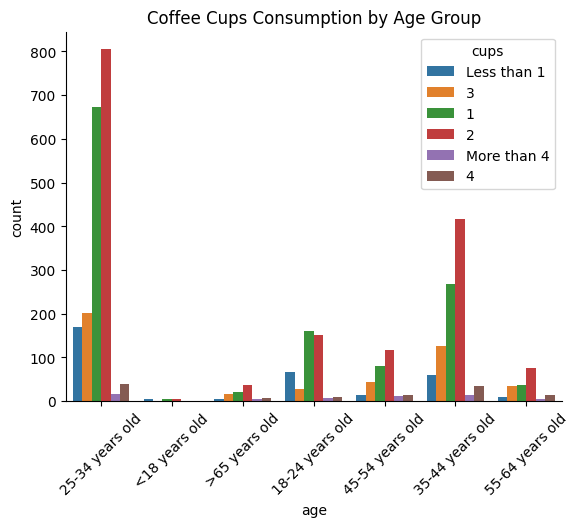

In [35]:
sns.countplot(data=df, x='age',hue='cups')             #age and number of cups they drink
plt.title('Coffee Cups Consumption by Age Group')
plt.xticks(rotation=45)
sns.despine()
plt.savefig('Coffee Cups Consumption by Age Group',dpi=300)
plt.show()

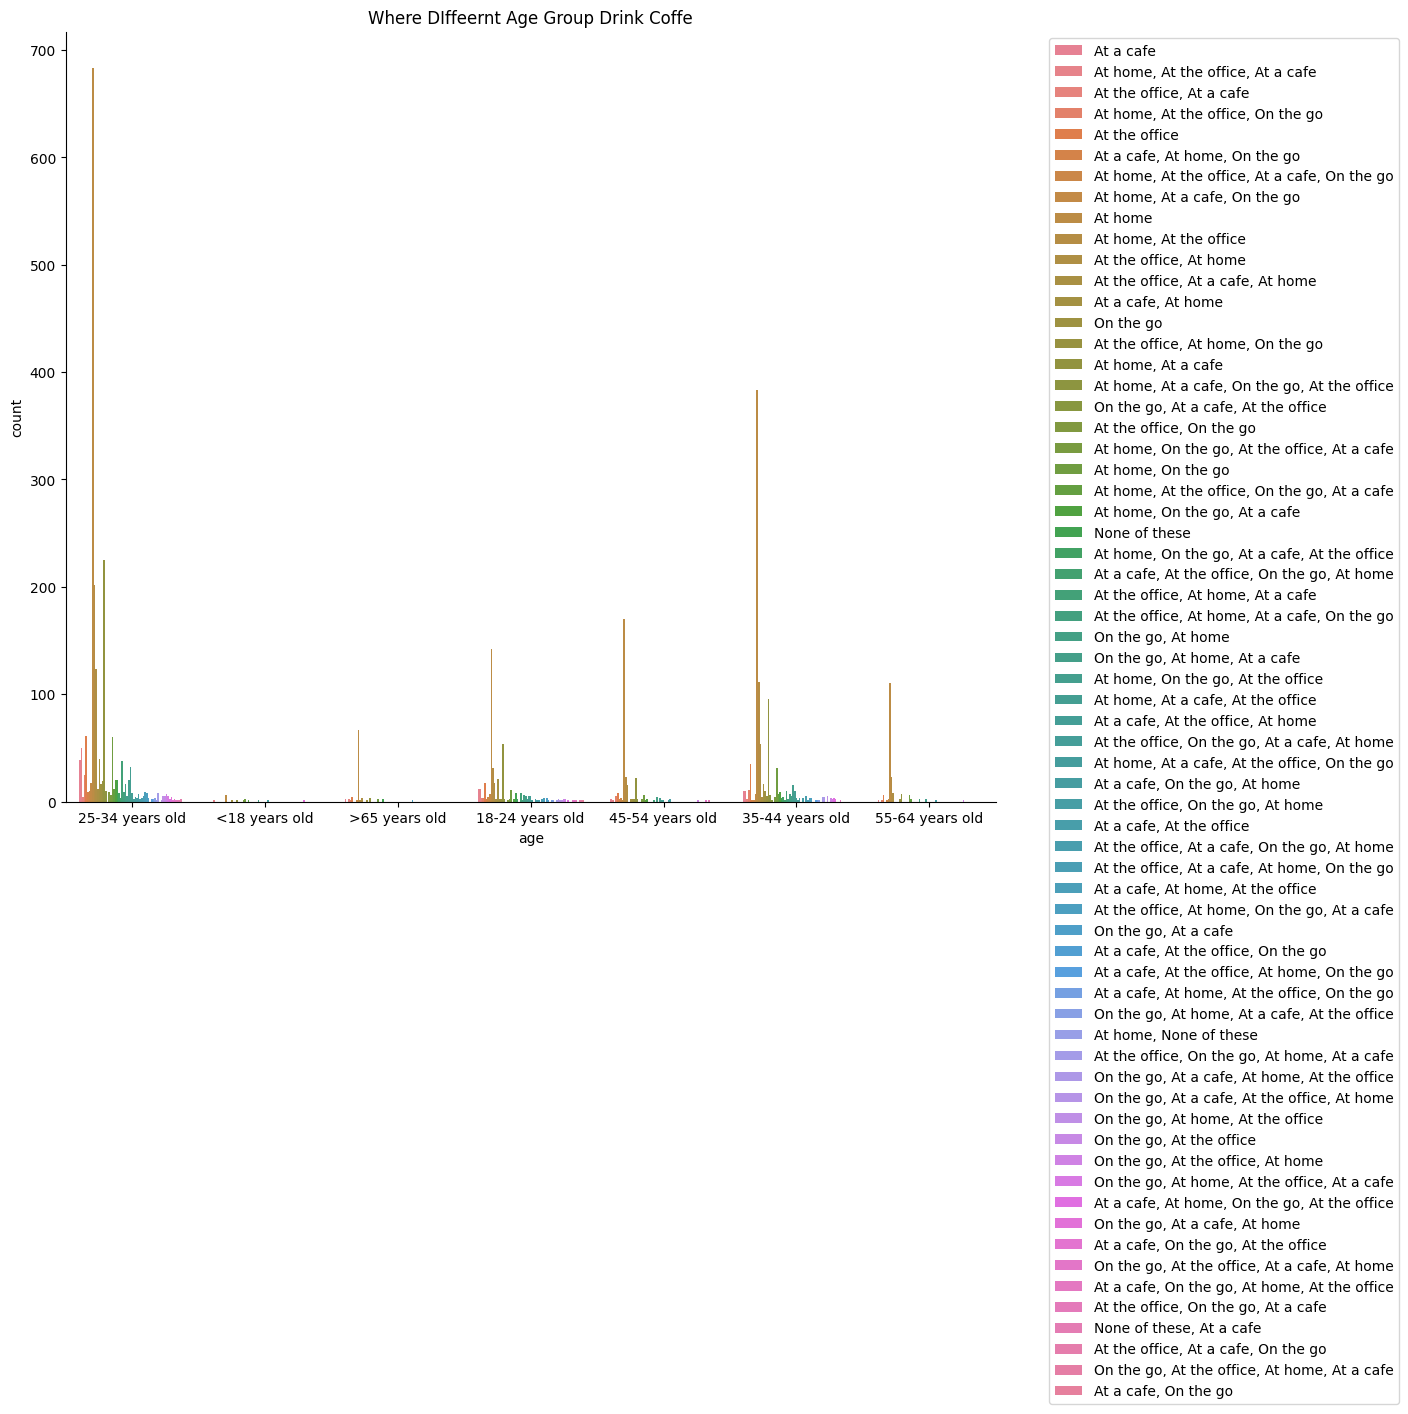

In [36]:
plt.figure(figsize=(12,10))
sns.countplot(data=df, hue='where_drink',x='age')             #age and where they drink
plt.title('Where DIffeernt Age Group Drink Coffe')
sns.despine()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('Where DIffeernt Age Group Drink Coffe',dpi=300)
plt.show()

In [37]:
taste_df = df[['coffee_a_personal_preference', 'coffee_b_personal_preference', 
              'coffee_c_personal_preference', 'coffee_d_personal_preference']].melt()
taste_df['variable'] = taste_df['variable'].str.replace('_personal_preference', '').str.upper()

plt.figure(figsize=(10, 6))
sns.barplot(data=taste_df, x='variable', y='value', errorbar=None)
plt.title('Which Coffee Won the Blind Taste Test?', fontsize=14, pad=15)
plt.xlabel('Coffee Type')
plt.ylabel('Average Preference Score (1-5)')
sns.despine()
plt.savefig('Which Coffee Won the Blind Taste Test?',dpi=300)
plt.show()

SyntaxError: unterminated string literal (detected at line 11) (2398345882.py, line 11)

In [29]:
df['spent_equipment'] = df['spent_equipment'].fillna(df['spent_equipment'].mode()[0])
df['value_equipment'] = df['value_equipment'].fillna(df['value_equipment'].mode()[0])
spending_order = [
    'Less than $20', 
    '$20-$50', 
    '$50-$100', 
    '$100-$300', 
    '$300-$500', 
    '$500-$1000'
]
plot_df = df[df['spent_equipment'].isin(spending_order)].copy()

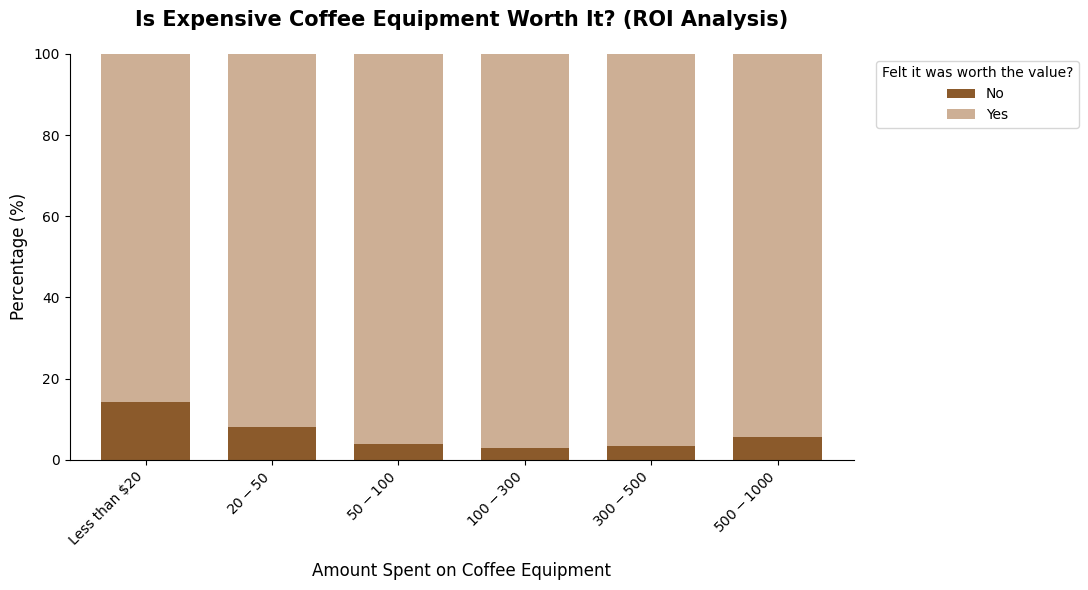

In [30]:
ct = pd.crosstab(plot_df['spent_equipment'], plot_df['value_equipment']) #i used cuz it summarize the relationship
ct = ct.reindex(spending_order)
ct_percentage = ct.div(ct.sum(axis=1), axis=0) * 100

plt.figure(figsize=(11, 6))
colors = ['#8B5A2B', '#CDaf95', '#d3d3d3']
ct_percentage.plot(kind='bar', stacked=True, color=colors, ax=plt.gca(), width=0.7)

plt.title('Is Expensive Coffee Equipment Worth It? (ROI Analysis)', fontsize=15, pad=20, weight='bold')
plt.xlabel('Amount Spent on Coffee Equipment', fontsize=12, labelpad=10)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)
plt.legend(title='Felt it was worth the value?', bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig('',dpi=300)
plt.show()

In [31]:
flavor_cols = [
    'coffee_a_bitterness', 'coffee_a_acidity', 'coffee_a_personal_preference',
    'coffee_b_bitterness', 'coffee_b_acidity', 'coffee_b_personal_preference',
    'coffee_c_bitterness', 'coffee_c_acidity', 'coffee_c_personal_preference',
    'coffee_d_bitterness', 'coffee_d_acidity', 'coffee_d_personal_preference'
]

for col in flavor_cols:
    df[col] = df[col].fillna(df[col].median())

corr_matrix = df[flavor_cols].corr()

short_labels = [
    'A Bitter', 'A Acid', 'A Pref',
    'B Bitter', 'B Acid', 'B Pref',
    'C Bitter', 'C Acid', 'C Pref',
    'D Bitter', 'D Acid', 'D Pref'
]
corr_matrix.columns = short_labels
corr_matrix.index = short_labels

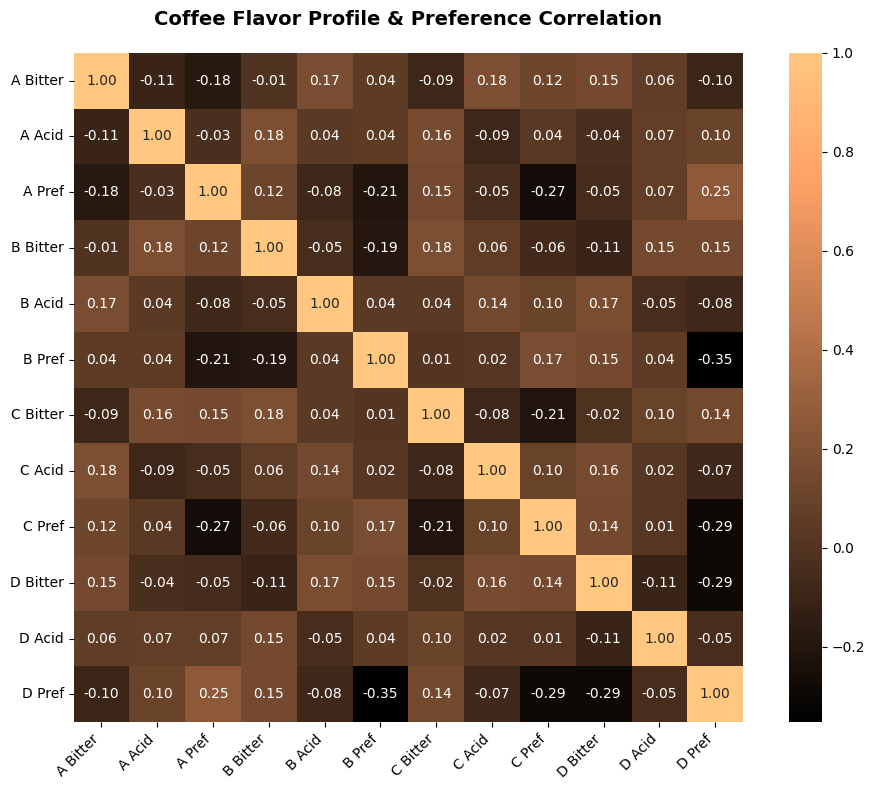

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="copper", cbar=True, square=True)

plt.title('Coffee Flavor Profile & Preference Correlation', fontsize=14, pad=20, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('',dpi=300)
plt.show()

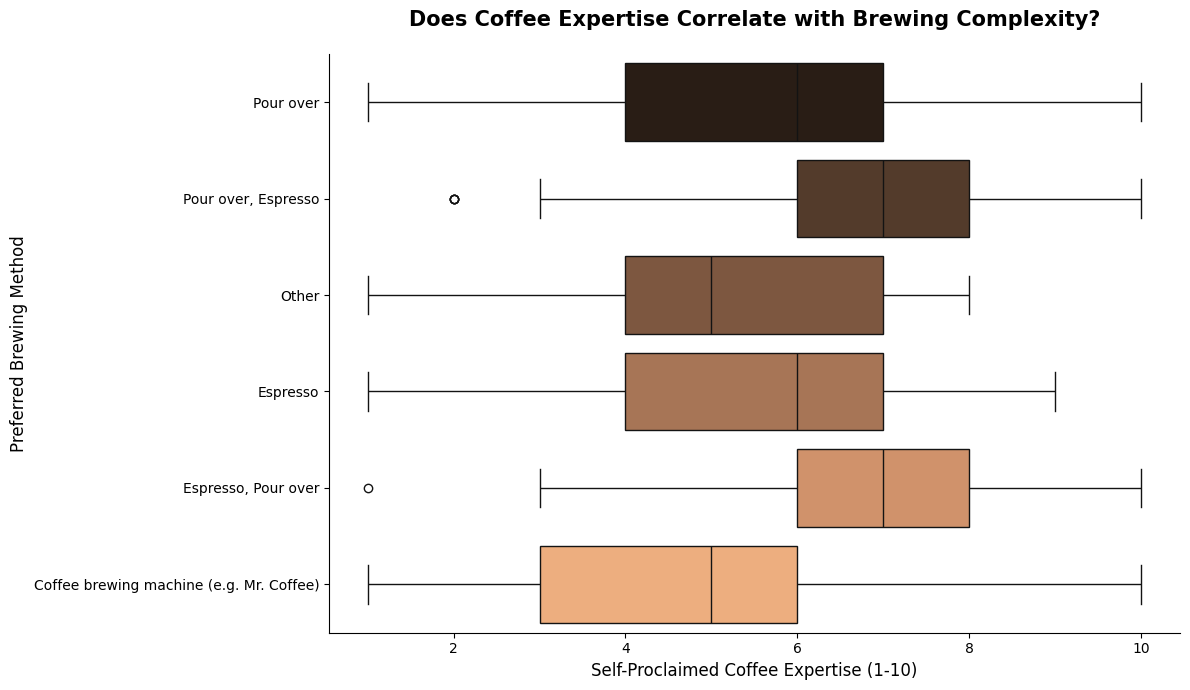

In [33]:
df['expertise'] = df['expertise'].fillna(df['expertise'].median())
df['brew'] = df['brew'].fillna(df['brew'].mode()[0])

top_brews = df['brew'].value_counts().index[:6]
filtered_df = df[df['brew'].isin(top_brews)]

plt.figure(figsize=(12, 7))
sns.boxplot(data=filtered_df, x='expertise', y='brew', palette='copper', hue='brew', legend=False)

plt.title('Does Coffee Expertise Correlate with Brewing Complexity?', fontsize=15, pad=20, weight='bold')
plt.xlabel('Self-Proclaimed Coffee Expertise (1-10)', fontsize=12)
plt.ylabel('Preferred Brewing Method', fontsize=12)

sns.despine()
plt.tight_layout()
plt.savefig('',dpi=300)
plt.show()